# HW1 — Introduction and Learnability
## PAC vs Agnostic PAC learning with threshold classifiers

**Course:** Statistical and Machine Learning — M2 IM / IMDS / MIAGE, Université de Haute-Alsace

---

### Objective
We illustrate experimentally the difference between the **PAC** (realizable) and the **Agnostic PAC** learning frameworks, using an Empirical Risk Minimization (ERM) learner over the class of threshold classifiers on $\mathcal X = [0,1]$:

$$\mathcal H = \{\, h_t : x \mapsto \mathbb 1[x > t] \;:\; t \in [0,1] \,\}, \qquad f_\theta(x) = \mathbb 1[x > \theta].$$

* **Realizable setting:** $y = f_\theta(x)$, so $f_\theta \in \mathcal H$ and $\min_{h\in\mathcal H} L_{\mathcal D}(h) = 0$.
* **Agnostic setting:** each label is flipped independently with probability $\eta$, so no hypothesis is perfect and $\min_{h\in\mathcal H} L_{\mathcal D}(h) = \eta$.

No machine-learning library is used: the ERM algorithm is written with NumPy only.

### Experimental choices

| Parameter | Value | Reason |
|---|---|---|
| target threshold $\theta$ | 0.3 | not at the centre, so the two classes are unbalanced (30% / 70%) |
| accuracy $\varepsilon$ | 0.05 | 5% error is a meaningful but reachable target |
| confidence $\delta$ | 0.05 | classical 95% confidence level |
| noise rate $\eta$ | 0.1 (main), plus 0.05, 0.2, 0.3 | moderate noise, then a sweep to see the effect of $\eta$ |
| training sizes $m$ | 5, 10, 20, 50, 100, 200 (+ 500, 1000, 2000 for the curves) | sizes required by the HW, extended to see the asymptotic behaviour |
| repetitions | 1000 (500 for the $\eta$ sweep) | the standard error of an estimated probability is then $\le 0.016$ |
| test set size | 100 000 | standard error of the estimated risk $\approx 0.001$ |

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ---------------- Experimental parameters (our own choices) ----------------
THETA   = 0.3            # target threshold θ (unknown to the learner)
EPS     = 0.05           # accuracy parameter ε
DELTA   = 0.05           # confidence parameter δ
ETA     = 0.1            # label-noise rate η (agnostic setting)
SIZES   = [5, 10, 20, 50, 100, 200]                    # sizes required by the HW
SIZES_EXT = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]  # extended range for the curves
N_REP   = 1000           # repetitions per training size
N_TEST  = 100_000        # size of the independent test set
SEED    = 42

rng = np.random.default_rng(SEED)

## 1. Data Generation

`generate_data(m, eta)` draws $x_1,\dots,x_m \sim \mathcal U[0,1]$ i.i.d., labels them with $f_\theta$, then (agnostic case) flips each label independently with probability $\eta$.

In [3]:
def target(x, theta=THETA):
    """Target threshold classifier f_θ(x) = 1 if x > θ else 0."""
    return (x > theta).astype(int)


def generate_data(m, theta=THETA, eta=0.0, rng=rng):
    """Draw m points uniformly on [0,1] and label them with f_θ.
    Each label is independently flipped with probability eta (eta = 0 -> realizable)."""
    x = rng.uniform(0.0, 1.0, size=m)
    y = target(x, theta)
    if eta > 0:
        flip = rng.random(m) < eta
        y = np.where(flip, 1 - y, y)
    return x, y

We generate one realizable training set for each required size $m \in \{5, 10, 20, 50, 100, 200\}$.

In [4]:
datasets = {m: generate_data(m) for m in SIZES}
for m, (x, y) in datasets.items():
    print(f"m = {m:4d} | #label 1 = {y.sum():4d} | #label 0 = {m - y.sum():4d}")

m =    5 | #label 1 =    4 | #label 0 =    1
m =   10 | #label 1 =    9 | #label 0 =    1
m =   20 | #label 1 =   15 | #label 0 =    5
m =   50 | #label 1 =   33 | #label 0 =   17
m =  100 | #label 1 =   71 | #label 0 =   29
m =  200 | #label 1 =  136 | #label 0 =   64


### Visualization of generated datasets
Points with label 0 are drawn at height 0, points with label 1 at height 1. The dashed line is the true threshold $\theta$.

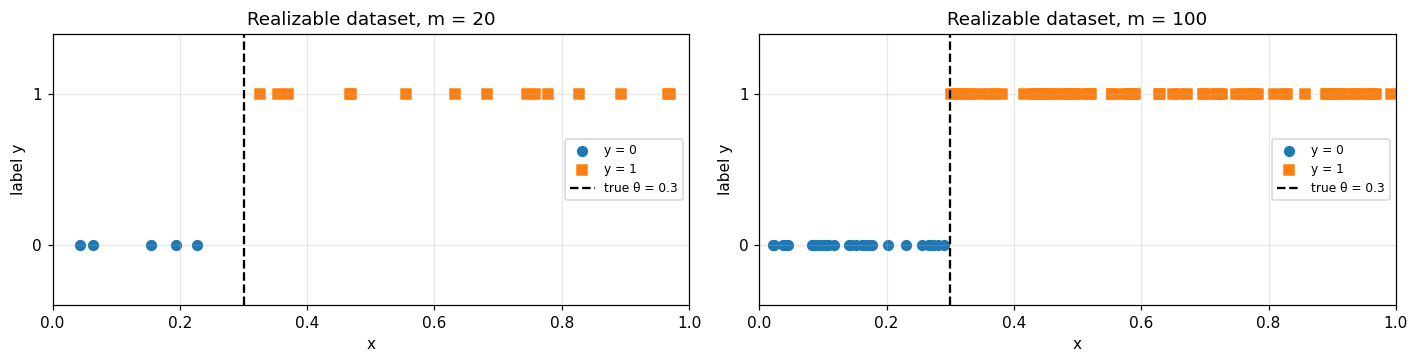

In [5]:
def plot_dataset(x, y, theta=THETA, title="", ax=None, h=None):
    ax = ax or plt.gca()
    ax.scatter(x[y == 0], np.zeros((y == 0).sum()), c="tab:blue",  marker="o", s=40, label="y = 0")
    ax.scatter(x[y == 1], np.ones((y == 1).sum()),  c="tab:orange", marker="s", s=40, label="y = 1")
    ax.axvline(theta, color="black", ls="--", lw=1.5, label=f"true θ = {theta}")
    if h is not None:
        ax.axvline(h, color="tab:red", lw=1.5, label=f"ERM threshold = {h:.3f}")
    ax.set_xlim(0, 1); ax.set_ylim(-0.4, 1.4)
    ax.set_yticks([0, 1]); ax.set_xlabel("x"); ax.set_ylabel("label y")
    ax.set_title(title); ax.legend(loc="center right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
plot_dataset(*datasets[20], title="Realizable dataset, m = 20", ax=axes[0])
plot_dataset(*datasets[100], title="Realizable dataset, m = 100", ax=axes[1])
plt.tight_layout(); plt.show()

**Comment.** In the realizable case the two classes are perfectly separated by $\theta$: every point left of the dashed line has label 0 and every point to the right has label 1. With $m=20$ there is a visible empty gap around $\theta$, inside which the learner cannot know where exactly the true threshold is; with $m=100$ this gap is much narrower. The size of this gap is exactly what controls the true error of ERM.

## 2. Implementation of ERM

**Strategy.** For a sample $S=\{(x_i,y_i)\}_{i=1}^m$, the empirical risk of $h_t$ is
$$L_S(h_t) = \frac1m \sum_{i=1}^m \mathbb 1[h_t(x_i) \ne y_i].$$
$L_S(h_t)$ only depends on **how many sample points lie to the left of $t$**, so it is piecewise constant in $t$. After sorting the points $x_{(1)} \le \dots \le x_{(m)}$, it is enough to test the $m+1$ positions

* $k=0$: $t$ left of all points (everything predicted 1),
* $k=1,\dots,m-1$: $t$ between $x_{(k)}$ and $x_{(k+1)}$,
* $k=m$: $t$ right of all points (everything predicted 0).

For position $k$ the number of mistakes is
$$\text{err}(k) = \underbrace{\#\{i\le k : y_{(i)}=1\}}_{\text{1's predicted 0}} + \underbrace{\#\{i> k : y_{(i)}=0\}}_{\text{0's predicted 1}},$$
which is computed for all $k$ at once with two cumulative sums. We pick $k^\star = \arg\min_k \text{err}(k)$ and return the **midpoint** of the corresponding gap as threshold.
Total cost: $O(m\log m)$ (sorting), instead of $O(m^2)$ for a naive search.

In the realizable case the minimum is always $0$ (the true $\theta$ falls in some gap), so this ERM is a *consistent* learner.

In [6]:
def erm_threshold(x, y):
    """ERM over the class H = {h_t : h_t(x) = 1[x > t], t in [0,1]}.

    Returns (t_hat, empirical_error).
    Strategy: only the position of t relative to the sorted sample matters,
    so we test m+1 candidate thresholds (one per gap between consecutive sorted points),
    compute every empirical error in O(m) with cumulative sums, and keep the best one.
    """
    m = len(x)
    order = np.argsort(x)
    xs, ys = x[order], y[order]

    # Candidate k (k = 0..m): the k smallest points are predicted 0, the others 1.
    # errors(k) = (#label-1 among the first k) + (#label-0 among the last m-k)
    ones_left  = np.concatenate(([0], np.cumsum(ys)))                 # length m+1
    zeros_right = np.concatenate((np.cumsum((1 - ys)[::-1])[::-1], [0]))
    errors = ones_left + zeros_right

    k = int(np.argmin(errors))           # first minimiser (any minimiser is a valid ERM)

    # Turn the index k into an actual threshold (midpoint of the gap)
    if k == 0:
        t = xs[0] / 2                    # everything predicted 1
    elif k == m:
        t = (xs[-1] + 1) / 2             # everything predicted 0
    else:
        t = (xs[k - 1] + xs[k]) / 2
    return t, errors[k] / m


def predict(t, x):
    return (x > t).astype(int)


def empirical_error(t, x, y):
    return np.mean(predict(t, x) != y)

**Sanity check.** We compare our ERM with a brute-force search over 20 001 thresholds on a noisy sample: both must find the same minimal empirical error.

In [7]:
# Sanity check: compare with a brute-force search on a fine grid
x, y = generate_data(50, eta=0.2)
t_hat, err_hat = erm_threshold(x, y)
grid = np.linspace(0, 1, 20001)
brute = min(empirical_error(t, x, y) for t in grid)
print(f"ERM threshold = {t_hat:.4f}, empirical error = {err_hat:.4f}, brute-force min = {brute:.4f}")
assert np.isclose(err_hat, brute)

ERM threshold = 0.3721, empirical error = 0.2400, brute-force min = 0.2400


## 3. Performance Evaluation

* **Empirical error** $L_S(h_S)$: error on the training set.
* **True error** $L_{\mathcal D}(h_S)$: estimated on an *independent* test set of 100 000 points.

Because $x\sim\mathcal U[0,1]$, the true error is also available in closed form: $h_t$ and $f_\theta$ disagree exactly on the interval between $t$ and $\theta$, so
$$L_{\mathcal D}(h_t) = |t-\theta| \quad\text{(realizable)}, \qquad L_{\mathcal D}(h_t) = \eta + (1-2\eta)\,|t-\theta| \quad\text{(noise } \eta\text{)}.$$
We print both, the closed form serving as a check of the test-set estimate.

In [8]:
# Independent large test set (one for each setting)
x_test_real, y_test_real = generate_data(N_TEST, eta=0.0)
x_test_agn,  y_test_agn  = generate_data(N_TEST, eta=ETA)


def true_error_analytic(t, theta=THETA, eta=0.0):
    """Exact risk for uniform X on [0,1]: the hypothesis disagrees with f_θ on an
    interval of length |t-θ|. With noise: L(h) = η + (1-2η)|t-θ|."""
    return eta + (1 - 2 * eta) * np.abs(t - theta)


print(f"{'m':>5} | {'t_hat':>7} | {'L_S(h)':>7} | {'L_D(h) test':>11} | {'L_D(h) exact':>12}")
print("-" * 55)
for m, (x, y) in datasets.items():
    t, emp = erm_threshold(x, y)
    test = empirical_error(t, x_test_real, y_test_real)
    print(f"{m:>5} | {t:7.4f} | {emp:7.4f} | {test:11.4f} | {true_error_analytic(t):12.4f}")

    m |   t_hat |  L_S(h) | L_D(h) test | L_D(h) exact
-------------------------------------------------------
    5 |  0.2665 |  0.0000 |      0.0329 |       0.0335
   10 |  0.2495 |  0.0000 |      0.0505 |       0.0505
   20 |  0.2765 |  0.0000 |      0.0228 |       0.0235
   50 |  0.2988 |  0.0000 |      0.0013 |       0.0012
  100 |  0.2962 |  0.0000 |      0.0037 |       0.0038
  200 |  0.2989 |  0.0000 |      0.0011 |       0.0011


**Comment.**
* The empirical error is **always exactly 0** in the realizable case: ERM always finds a threshold consistent with the sample.
* The true error is **positive** and is larger than the empirical error: $L_S$ is an optimistic estimate of $L_{\mathcal D}$. The gap shrinks when $m$ grows (from a few % for $m\le 20$ to about 0.1% for $m=200$), because the learned threshold $\hat t$ gets closer to $\theta = 0.3$.
* The test-set estimate and the exact value agree to about $10^{-3}$, as expected for $N_{\text{test}}=10^5$ ($\sqrt{0.05\cdot0.95/10^5}\approx 7\cdot10^{-4}$).

The learned threshold (red) compared with the true one (dashed) for three sample sizes:

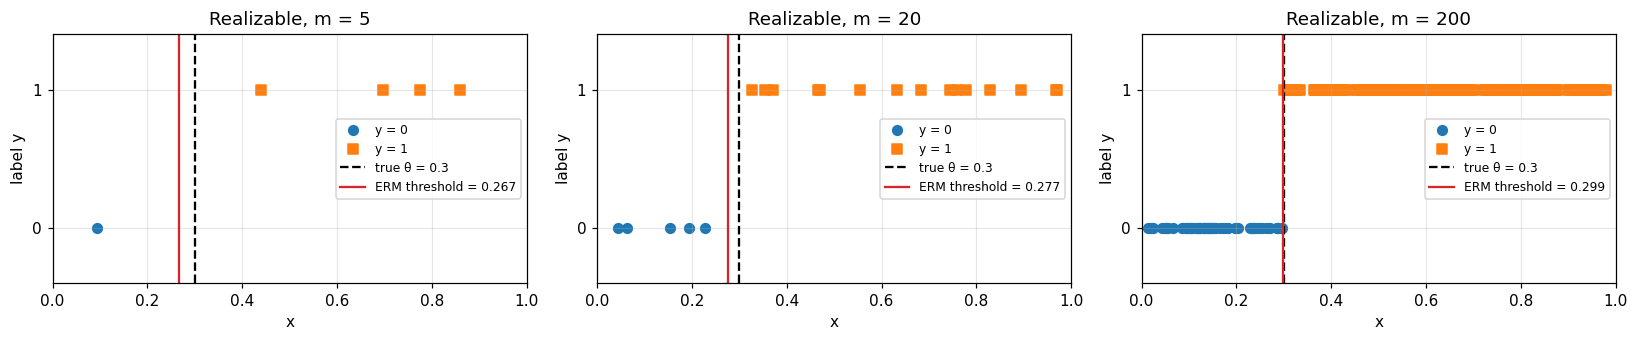

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, m in zip(axes, [5, 20, 200]):
    x, y = datasets[m]
    plot_dataset(x, y, ax=ax, h=erm_threshold(x, y)[0], title=f"Realizable, m = {m}")
plt.tight_layout(); plt.show()

## 4. Experimental Verification of PAC Learning

**Definition (PAC).** $\mathcal H$ is PAC learnable if there is an $m_{\mathcal H}(\varepsilon,\delta)$ such that for every $m\ge m_{\mathcal H}(\varepsilon,\delta)$, with probability at least $1-\delta$ over $S\sim\mathcal D^m$, $L_{\mathcal D}(h_S)\le\varepsilon$, i.e.
$$\Pr_S\big(L_{\mathcal D}(h_S)>\varepsilon\big) \le \delta .$$

**Theoretical bound for thresholds.** $L_{\mathcal D}(h_S)>\varepsilon$ requires that no sample point falls in $(\theta-\varepsilon,\theta]$ **or** none in $(\theta,\theta+\varepsilon]$ (otherwise the learned threshold is $\varepsilon$-close to $\theta$ on that side). By a union bound,
$$\Pr\big(L_{\mathcal D}(h_S)>\varepsilon\big) \le 2(1-\varepsilon)^m \le 2e^{-\varepsilon m}
\;\Longrightarrow\; m_{\mathcal H}(\varepsilon,\delta) \le \Big\lceil \frac{\ln(2/\delta)}{\varepsilon}\Big\rceil .$$

**Protocol.** For every $m$ we repeat 1000 times: draw a fresh training set, run ERM, record $L_S(h_S)$ and $L_{\mathcal D}(h_S)$. The probability $\Pr(L_{\mathcal D}(h_S)>\varepsilon)$ is estimated by the fraction of repetitions where the true error exceeds $\varepsilon$.

To keep the run fast, $L_{\mathcal D}(h_S)$ is computed with the closed form above, which is exactly what the 100 000-point test set estimates (we check this below).

In [9]:
def run_experiment(sizes, eta, n_rep=N_REP, theta=THETA, rng=rng):
    """For each m, repeat n_rep times: sample S, run ERM, record empirical and true errors.
    The true error is the exact risk |t-θ|(1-2η)+η, which equals the limit of the test-set
    error (agreement with the 100 000-point test set is checked in the next cell)."""
    res = {}
    for m in sizes:
        emp, true = np.empty(n_rep), np.empty(n_rep)
        for r in range(n_rep):
            x, y = generate_data(m, theta=theta, eta=eta, rng=rng)
            t, emp[r] = erm_threshold(x, y)
            true[r] = true_error_analytic(t, theta, eta)
        res[m] = dict(emp=emp, true=true)
    return res

### Realizable setting ($\eta = 0$)

In [10]:
res_real = run_experiment(SIZES_EXT, eta=0.0)

# check: risk on the test set vs exact risk (on a subset of repetitions, for m = 20)
rng_chk = np.random.default_rng(1)
diffs = []
for _ in range(100):
    x, y = generate_data(20, rng=rng_chk)
    t, _ = erm_threshold(x, y)
    diffs.append(abs(empirical_error(t, x_test_real, y_test_real) - true_error_analytic(t)))
print(f"max |test-set error - exact risk| over 100 runs = {max(diffs):.4f}  (≈ O(1/sqrt(N_TEST)))")

max |test-set error - exact risk| over 100 runs = 0.0010  (≈ O(1/sqrt(N_TEST)))


### Results table

In [11]:
def summarize(res, eps, baseline=0.0):
    rows = []
    for m, r in res.items():
        rows.append(dict(
            m=m,
            mean_emp=r["emp"].mean(),
            mean_true=r["true"].mean(),
            p_fail=np.mean(r["true"] > eps),                 # Pr(L(h) > ε)
            p_fail_excess=np.mean(r["true"] - baseline > eps) # Pr(L(h) - L(h*) > ε)
        ))
    return rows


rows_real = summarize(res_real, EPS)
print(f"Realizable setting, ε = {EPS}, θ = {THETA}, {N_REP} repetitions")
print(f"{'m':>5} | {'mean L_S':>8} | {'mean L_D':>8} | {'Pr(L_D > ε)':>11} | {'bound 2(1-ε)^m':>14}")
print("-" * 60)
for r in rows_real:
    bound = min(1.0, 2 * (1 - EPS) ** r["m"])
    print(f"{r['m']:>5} | {r['mean_emp']:8.4f} | {r['mean_true']:8.4f} | {r['p_fail']:11.3f} | {bound:14.4f}")

m_pac = int(np.ceil(np.log(2 / DELTA) / EPS))
print(f"\nTheoretical sample size for (ε, δ) = ({EPS}, {DELTA}):  m ≥ ln(2/δ)/ε = {m_pac}")

Realizable setting, ε = 0.05, θ = 0.3, 1000 repetitions
    m | mean L_S | mean L_D | Pr(L_D > ε) | bound 2(1-ε)^m
------------------------------------------------------------
    5 |   0.0000 |   0.0700 |       0.545 |         1.0000
   10 |   0.0000 |   0.0458 |       0.354 |         1.0000
   20 |   0.0000 |   0.0238 |       0.118 |         0.7170
   50 |   0.0000 |   0.0093 |       0.004 |         0.1539
  100 |   0.0000 |   0.0050 |       0.000 |         0.0118
  200 |   0.0000 |   0.0025 |       0.000 |         0.0001
  500 |   0.0000 |   0.0010 |       0.000 |         0.0000
 1000 |   0.0000 |   0.0005 |       0.000 |         0.0000
 2000 |   0.0000 |   0.0003 |       0.000 |         0.0000

Theoretical sample size for (ε, δ) = (0.05, 0.05):  m ≥ ln(2/δ)/ε = 74


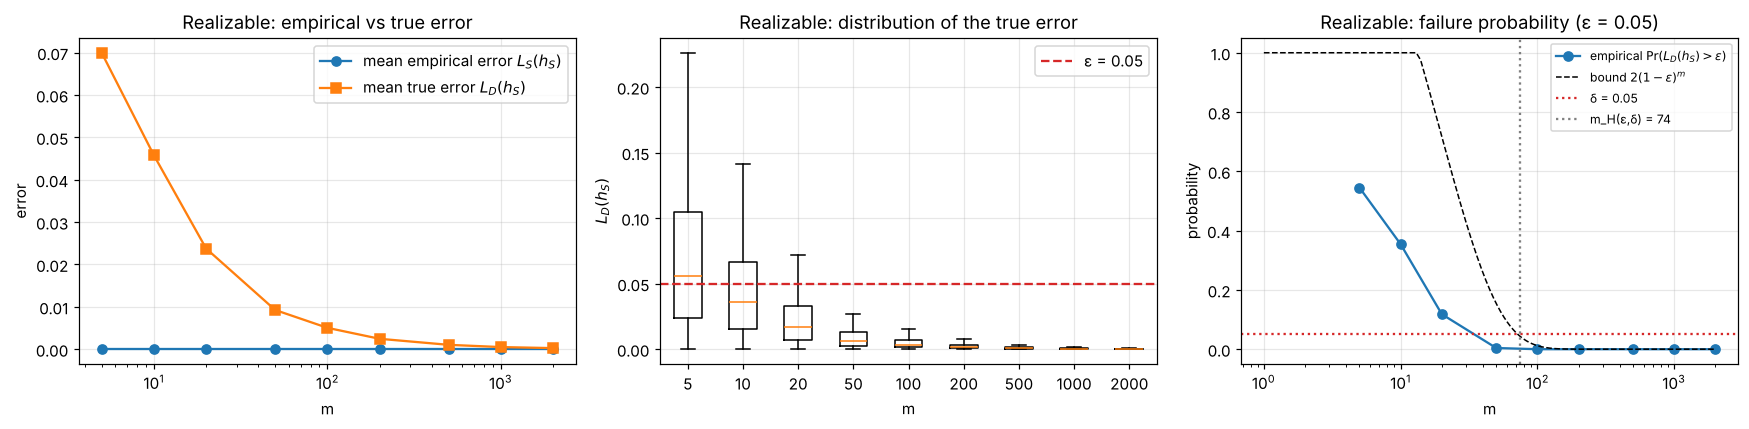

In [12]:
ms = np.array(SIZES_EXT)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) empirical vs true error
axes[0].plot(ms, [r["mean_emp"] for r in rows_real], "o-", label="mean empirical error $L_S(h_S)$")
axes[0].plot(ms, [r["mean_true"] for r in rows_real], "s-", label="mean true error $L_D(h_S)$")
axes[0].set_xscale("log"); axes[0].set_xlabel("m"); axes[0].set_ylabel("error")
axes[0].set_title("Realizable: empirical vs true error"); axes[0].legend()

# (b) distribution of the true error
axes[1].boxplot([res_real[m]["true"] for m in SIZES_EXT], tick_labels=SIZES_EXT, showfliers=False)
axes[1].axhline(EPS, color="tab:red", ls="--", label=f"ε = {EPS}")
axes[1].set_xlabel("m"); axes[1].set_ylabel("$L_D(h_S)$")
axes[1].set_title("Realizable: distribution of the true error"); axes[1].legend()

# (c) Pr(L > ε)
m_grid = np.arange(1, 2001)
axes[2].plot(ms, [r["p_fail"] for r in rows_real], "o-", label=r"empirical $\Pr(L_D(h_S) > \varepsilon)$")
axes[2].plot(m_grid, np.minimum(1, 2 * (1 - EPS) ** m_grid), "k--", lw=1, label=r"bound $2(1-\varepsilon)^m$")
axes[2].axhline(DELTA, color="tab:red", ls=":", label=f"δ = {DELTA}")
axes[2].axvline(m_pac, color="gray", ls=":", label=f"m_H(ε,δ) = {m_pac}")
axes[2].set_xscale("log"); axes[2].set_xlabel("m"); axes[2].set_ylabel("probability")
axes[2].set_title(f"Realizable: failure probability (ε = {EPS})"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation of the realizable experiment

* **Empirical error:** always 0 for every $m$ and every repetition (the problem is realizable and ERM is consistent).
* **True error:** the mean true error decreases like $1/m$ (0.07 at $m=5$, 0.005 at $m=100$, 0.00025 at $m=2000$; doubling $m$ halves the error). This is the classical *fast rate* of the realizable case: the expected gap around $\theta$ has length of order $1/m$.
* **Failure probability:** $\Pr(L_{\mathcal D}(h_S)>0.05)$ falls from 0.55 at $m=5$ to 0.12 at $m=20$, 0.004 at $m=50$ and 0 from $m=100$ on. It decreases **exponentially** in $m$, as predicted by $2(1-\varepsilon)^m$.
* **Theory vs experiment:** the empirical curve is always below the bound $2(1-\varepsilon)^m$ (the bound is valid but pessimistic, because of the union bound and of $1-\varepsilon\le e^{-\varepsilon}$). The theory asks for $m\ge 74$ to guarantee $\delta=0.05$; in practice $m=50$ is already enough.
* The boxplots show that not only the mean but the **whole distribution** of the true error concentrates towards 0.

Same experiment for several accuracy levels $\varepsilon$: the smaller $\varepsilon$, the more examples are needed to reach a failure probability below $\delta$ (the required $m$ scales like $1/\varepsilon$).

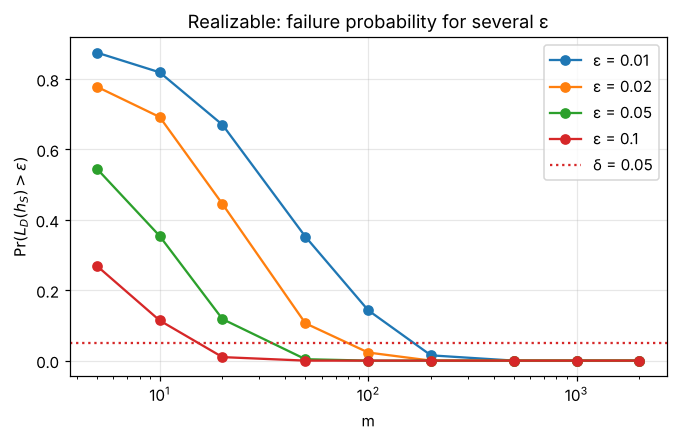

In [13]:
eps_list = [0.01, 0.02, 0.05, 0.1]
plt.figure(figsize=(7, 4))
for e in eps_list:
    plt.plot(ms, [np.mean(res_real[m]["true"] > e) for m in SIZES_EXT], "o-", label=f"ε = {e}")
plt.axhline(DELTA, color="tab:red", ls=":", label=f"δ = {DELTA}")
plt.xscale("log"); plt.xlabel("m"); plt.ylabel(r"$\Pr(L_D(h_S) > \varepsilon)$")
plt.title("Realizable: failure probability for several ε"); plt.legend(); plt.show()

## 5. From PAC to Agnostic PAC

We now flip each training (and test) label with probability $\eta = 0.1$. The target $f_\theta$ is still the best hypothesis of $\mathcal H$ (because $\eta<1/2$), but its error is no longer 0:
$$L_{\mathcal D}(h^\star) = \min_{h\in\mathcal H} L_{\mathcal D}(h) = \eta = 0.1 .$$

**Definition (Agnostic PAC).** $\mathcal H$ is agnostic PAC learnable if for $m\ge m_{\mathcal H}(\varepsilon,\delta)$,
$$\Pr_S\Big(L_{\mathcal D}(h_S) > \min_{h\in\mathcal H}L_{\mathcal D}(h) + \varepsilon\Big) \le \delta .$$
The guarantee is now **relative** to the best hypothesis of the class, not absolute.

### Noisy datasets

    m |   t_hat |  L_S(h) | L_D(h) test | L_D(h) exact
-------------------------------------------------------
    5 |  0.3186 |  0.0000 |      0.1147 |       0.1149
   10 |  0.2669 |  0.0000 |      0.1261 |       0.1265
   20 |  0.3060 |  0.1500 |      0.1044 |       0.1048
   50 |  0.2922 |  0.1600 |      0.1060 |       0.1062
  100 |  0.3022 |  0.0800 |      0.1013 |       0.1017
  200 |  0.2908 |  0.0950 |      0.1070 |       0.1073

Best achievable error in H: L_D(h*) = η = 0.1


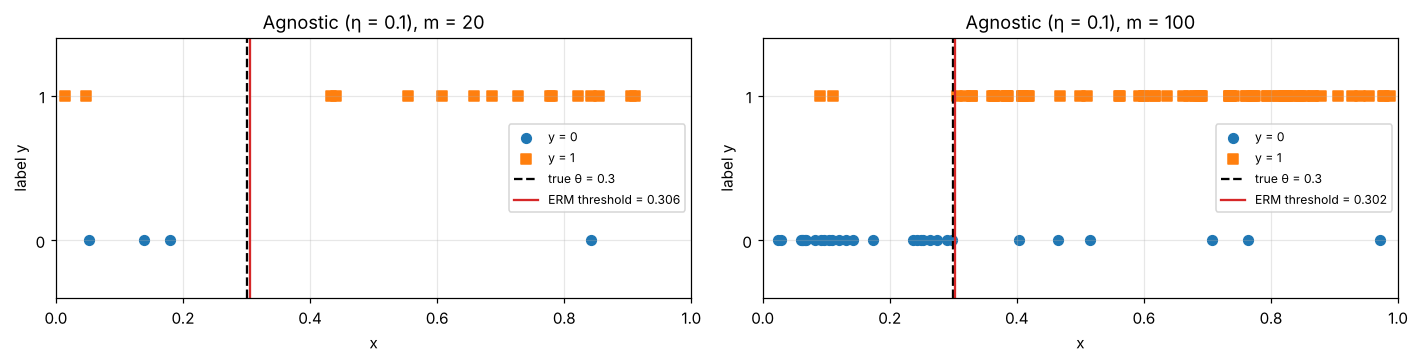

In [14]:
noisy = {m: generate_data(m, eta=ETA) for m in SIZES}
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, m in zip(axes, [20, 100]):
    x, y = noisy[m]
    plot_dataset(x, y, ax=ax, h=erm_threshold(x, y)[0], title=f"Agnostic (η = {ETA}), m = {m}")
plt.tight_layout(); plt.show()

print(f"{'m':>5} | {'t_hat':>7} | {'L_S(h)':>7} | {'L_D(h) test':>11} | {'L_D(h) exact':>12}")
print("-" * 55)
for m, (x, y) in noisy.items():
    t, emp = erm_threshold(x, y)
    test = empirical_error(t, x_test_agn, y_test_agn)
    print(f"{m:>5} | {t:7.4f} | {emp:7.4f} | {test:11.4f} | {true_error_analytic(t, eta=ETA):12.4f}")
print(f"\nBest achievable error in H: L_D(h*) = η = {ETA}")

**Comment.** Some labels now lie on the "wrong side" of $\theta$ (blue points on the right, orange points on the left). No threshold can separate the classes perfectly. For small samples it may happen that no label was flipped, and then the empirical error is still 0, but as soon as $m\ge 20$ the empirical error is positive and close to $\eta$. The true error stays **above 0.1** for every $m$, but gets closer and closer to it.

### Repeated experiment in the agnostic setting

We evaluate two criteria:
* $\Pr(L_{\mathcal D}(h_S)>\varepsilon)$ — the **realizable PAC** criterion;
* $\Pr(L_{\mathcal D}(h_S)-L_{\mathcal D}(h^\star)>\varepsilon)$ — the **agnostic PAC** criterion, with $L_{\mathcal D}(h^\star)=\eta$.

In [15]:
res_agn = run_experiment(SIZES_EXT, eta=ETA)
rows_agn = summarize(res_agn, EPS, baseline=ETA)

print(f"Agnostic setting, η = {ETA}, ε = {EPS}, {N_REP} repetitions   (L_D(h*) = {ETA})")
print(f"{'m':>5} | {'mean L_S':>8} | {'Pr(L_S=0)':>9} | {'mean L_D':>8} | {'Pr(L_D > ε)':>11} | {'Pr(L_D - L* > ε)':>16}")
print("-" * 75)
for m, r in zip(SIZES_EXT, rows_agn):
    p_zero = np.mean(res_agn[m]["emp"] == 0)
    print(f"{m:>5} | {r['mean_emp']:8.4f} | {p_zero:9.3f} | {r['mean_true']:8.4f} | {r['p_fail']:11.3f} | {r['p_fail_excess']:16.3f}")

Agnostic setting, η = 0.1, ε = 0.05, 1000 repetitions   (L_D(h*) = 0.1)
    m | mean L_S | Pr(L_S=0) | mean L_D | Pr(L_D > ε) | Pr(L_D - L* > ε)
---------------------------------------------------------------------------
    5 |   0.0646 |     0.706 |   0.1884 |       1.000 |            0.627
   10 |   0.0758 |     0.441 |   0.1630 |       1.000 |            0.431
   20 |   0.0854 |     0.156 |   0.1358 |       1.000 |            0.228
   50 |   0.0948 |     0.001 |   0.1165 |       1.000 |            0.073
  100 |   0.0968 |     0.000 |   0.1077 |       1.000 |            0.008
  200 |   0.0995 |     0.000 |   0.1038 |       1.000 |            0.000
  500 |   0.0998 |     0.000 |   0.1016 |       1.000 |            0.000
 1000 |   0.0999 |     0.000 |   0.1008 |       1.000 |            0.000
 2000 |   0.0999 |     0.000 |   0.1004 |       1.000 |            0.000


### Comparison of the two settings

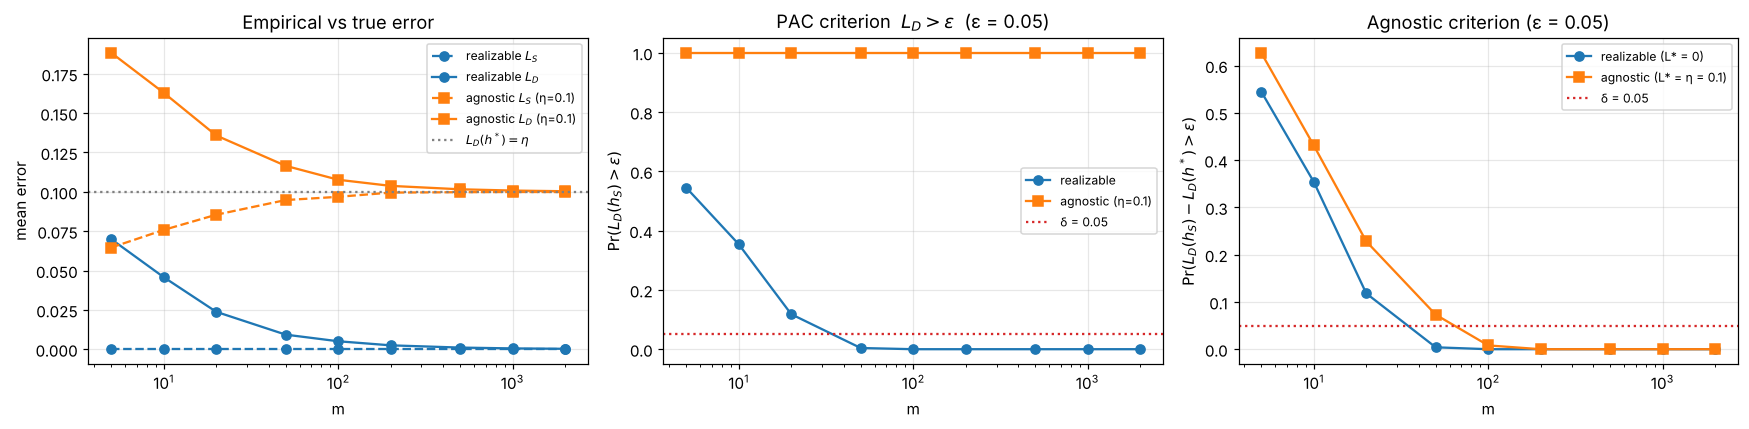

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) empirical vs true error, both settings
axes[0].plot(ms, [r["mean_emp"] for r in rows_real], "o--", c="tab:blue", label="realizable $L_S$")
axes[0].plot(ms, [r["mean_true"] for r in rows_real], "o-", c="tab:blue", label="realizable $L_D$")
axes[0].plot(ms, [r["mean_emp"] for r in rows_agn], "s--", c="tab:orange", label=f"agnostic $L_S$ (η={ETA})")
axes[0].plot(ms, [r["mean_true"] for r in rows_agn], "s-", c="tab:orange", label=f"agnostic $L_D$ (η={ETA})")
axes[0].axhline(ETA, color="gray", ls=":", label=r"$L_D(h^*) = \eta$")
axes[0].set_xscale("log"); axes[0].set_xlabel("m"); axes[0].set_ylabel("mean error")
axes[0].set_title("Empirical vs true error"); axes[0].legend(fontsize=8)

# (b) Pr(L > ε): the realizable criterion applied to both settings
axes[1].plot(ms, [r["p_fail"] for r in rows_real], "o-", label="realizable")
axes[1].plot(ms, [r["p_fail"] for r in rows_agn], "s-", label=f"agnostic (η={ETA})")
axes[1].axhline(DELTA, color="tab:red", ls=":", label=f"δ = {DELTA}")
axes[1].set_xscale("log"); axes[1].set_xlabel("m"); axes[1].set_ylabel(r"$\Pr(L_D(h_S) > \varepsilon)$")
axes[1].set_title(f"PAC criterion  $L_D > \\varepsilon$  (ε = {EPS})"); axes[1].legend(fontsize=8)

# (c) Pr(L - L* > ε): the agnostic criterion
axes[2].plot(ms, [r["p_fail"] for r in rows_real], "o-", label="realizable (L* = 0)")
axes[2].plot(ms, [r["p_fail_excess"] for r in rows_agn], "s-", label=f"agnostic (L* = η = {ETA})")
axes[2].axhline(DELTA, color="tab:red", ls=":", label=f"δ = {DELTA}")
axes[2].set_xscale("log"); axes[2].set_xlabel("m"); axes[2].set_ylabel(r"$\Pr(L_D(h_S) - L_D(h^*) > \varepsilon)$")
axes[2].set_title(f"Agnostic criterion (ε = {EPS})"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation

* **Left panel.** In the realizable case $L_S$ is stuck at 0 and $L_{\mathcal D}\to 0$. In the agnostic case **both** errors converge to $\eta=0.1$: the empirical error from **below** (ERM overfits the noise of the sample, so $L_S(h_S)$ is optimistic) and the true error from **above**. The noise sets a floor that no amount of data can remove.
* **Middle panel.** With the realizable criterion, the failure probability is **1 for every $m$** in the agnostic setting: since $L_{\mathcal D}(h)\ge\eta=0.1>\varepsilon$ for every $h$, the event $L_{\mathcal D}(h_S)\le 0.05$ is impossible. The PAC guarantee in its realizable form simply cannot be met.
* **Right panel.** With the agnostic criterion (excess risk over $h^\star$), the failure probability again goes to 0: 0.63 at $m=5$, 0.07 at $m=50$, 0.008 at $m=100$, 0 from $m=200$. ERM is therefore an agnostic PAC learner, but it needs **more examples** than in the realizable case for the same $(\varepsilon,\delta)$ (≈100 instead of ≈50 here).

### Effect of the noise level $\eta$

We repeat the agnostic experiment for $\eta \in \{0, 0.05, 0.1, 0.2, 0.3\}$ (500 repetitions each).

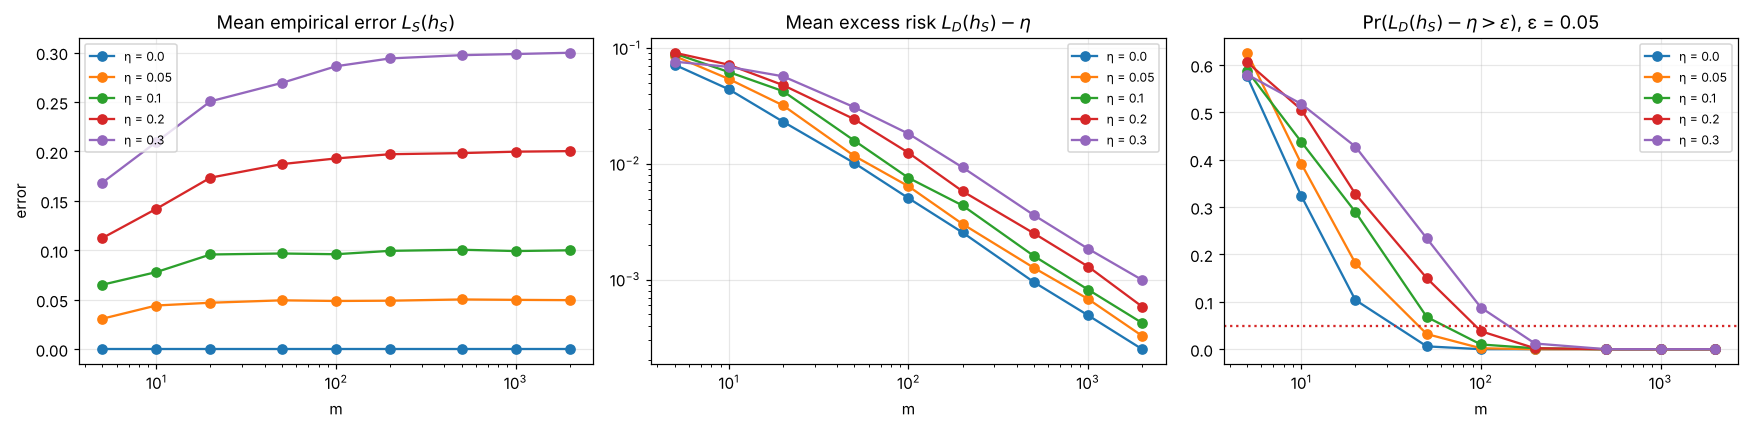

In [17]:
etas = [0.0, 0.05, 0.1, 0.2, 0.3]
res_by_eta = {eta: run_experiment(SIZES_EXT, eta=eta, n_rep=500) for eta in etas}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for eta, res in res_by_eta.items():
    axes[0].plot(ms, [res[m]["emp"].mean() for m in SIZES_EXT], "o-", label=f"η = {eta}")
    axes[1].plot(ms, [res[m]["true"].mean() - eta for m in SIZES_EXT], "o-", label=f"η = {eta}")
    axes[2].plot(ms, [np.mean(res[m]["true"] - eta > EPS) for m in SIZES_EXT], "o-", label=f"η = {eta}")
axes[0].set_title("Mean empirical error $L_S(h_S)$"); axes[0].set_ylabel("error")
axes[1].set_title("Mean excess risk $L_D(h_S) - \\eta$"); axes[1].set_yscale("log")
axes[2].set_title(f"$\\Pr(L_D(h_S) - \\eta > \\varepsilon)$, ε = {EPS}")
axes[2].axhline(DELTA, color="tab:red", ls=":")
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("m"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Comment.**
* **Left:** the empirical error converges to $\eta$; it is 0 only for $\eta=0$.
* **Middle:** the excess risk $L_{\mathcal D}(h_S)-\eta$ goes to 0 for every noise level, but more slowly when $\eta$ is larger (curves shifted upwards). Near $\eta=1/2$ the two classes become almost indistinguishable and learning gets much harder.
* **Right:** the sample size needed to have $\Pr(\text{excess} > 0.05) \le 0.05$ grows with $\eta$: about 50 for $\eta=0$, about 100 for $\eta=0.1$, about 150–200 for $\eta=0.3$.
* Remark: the general agnostic theory (uniform convergence, VC dimension 1) only guarantees an excess risk of order $\sqrt{\ln(1/\delta)/m}$, i.e. $m=O(\ln(1/\delta)/\varepsilon^2)$. Here the excess risk still decays roughly like $1/m$, because our noise is uniform with $\eta<1/2$ (a "benign" noise, the Bayes classifier belongs to $\mathcal H$); the price of the noise is a larger constant, not a worse rate. The $1/\varepsilon^2$ rate is a **worst case** over all distributions.

### Generalization gap
The difference $L_{\mathcal D}(h_S)-L_S(h_S)$ measures how optimistic the training error is.

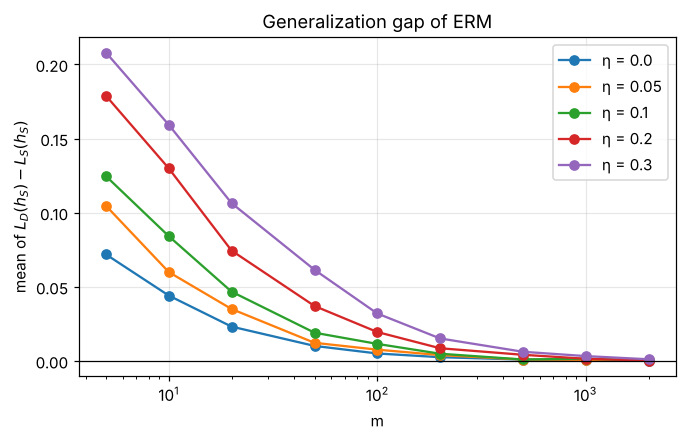

In [18]:
# Optimism of the empirical error: gap L_D(h_S) - L_S(h_S)
plt.figure(figsize=(7, 4))
for eta, res in res_by_eta.items():
    plt.plot(ms, [(res[m]["true"] - res[m]["emp"]).mean() for m in SIZES_EXT], "o-", label=f"η = {eta}")
plt.xscale("log"); plt.xlabel("m"); plt.ylabel(r"mean of $L_D(h_S) - L_S(h_S)$")
plt.title("Generalization gap of ERM"); plt.axhline(0, color="k", lw=0.8); plt.legend(); plt.show()

**Comment.** The gap is always positive (the training error under-estimates the true error) and goes to 0 when $m$ grows: this is **uniform convergence**, the property that makes ERM work in both frameworks. The gap is larger with more noise, because ERM can place its threshold so as to "explain" some of the flipped labels.

## 6. Answers to the questions

**Can the empirical error still reach zero?**
Only by chance, for very small samples in which no label happened to be flipped (≈70% of the runs at $m=5$, ≈16% at $m=20$, never from $m=100$ with $\eta=0.1$). For large $m$ the empirical error converges to $\eta>0$: about a fraction $\eta$ of the labels contradicts every threshold, so no hypothesis of $\mathcal H$ can be consistent with the sample. In the realizable setting, on the contrary, the empirical error is 0 in 100% of the runs.

**Does increasing the number of training examples still improve generalization?**
Yes, but in a **relative** sense. The true error decreases with $m$ and converges to $\eta=0.1$, never to 0. What tends to 0 is the excess risk $L_{\mathcal D}(h_S)-\min_{h}L_{\mathcal D}(h)$, and the probability that this excess exceeds $\varepsilon$ tends to 0. More data allows ERM to get as close as we want to the best hypothesis of the class, not to perfect classification.

**Link with the PAC and Agnostic PAC frameworks.**
* The realizable experiment confirms PAC learnability of thresholds: with $m\ge m_{\mathcal H}(\varepsilon,\delta)$, $\Pr(L_{\mathcal D}(h_S)>\varepsilon)\le\delta$, and the failure probability decreases exponentially like the bound $2(1-\varepsilon)^m$ ($m_{\mathcal H}(0.05,0.05)\le 74$; observed: ~50).
* In the agnostic setting the realizable condition $L_{\mathcal D}(h_S)\le\varepsilon$ is unreachable whenever $\varepsilon<\eta$ (failure probability = 1 for all $m$). The right notion is the agnostic one, $L_{\mathcal D}(h_S)\le \min_h L_{\mathcal D}(h)+\varepsilon$, which ERM satisfies once $m$ is large enough, as guaranteed by uniform convergence for a class of finite VC dimension (VC dim = 1 here).
* The price of agnostic learning is a larger sample complexity, which grows with the noise level.

## 7. Conclusion

| | **PAC (realizable)** | **Agnostic PAC (noise $\eta$)** |
|---|---|---|
| Best error in $\mathcal H$ | $0$ | $\eta$ (here 0.1) |
| Empirical error of ERM | always 0 | $>0$, converges to $\eta$ from below |
| True error of ERM | $\to 0$ like $1/m$ | $\to \eta$, never below it |
| Guarantee | $\Pr(L_{\mathcal D}(h_S)>\varepsilon)\le\delta$ | $\Pr(L_{\mathcal D}(h_S)>L_{\mathcal D}(h^\star)+\varepsilon)\le\delta$ |
| Realizable criterion with $\varepsilon<\eta$ | satisfied for $m \gtrsim 50$ | **never** satisfied (probability 1) |
| Sample size for $\varepsilon=\delta=0.05$ (observed) | ≈ 50 | ≈ 100 ($\eta=0.1$), ≈ 200 ($\eta=0.3$) |
| Theoretical sample complexity | $O\big(\ln(1/\delta)/\varepsilon\big)$ | $O\big(\ln(1/\delta)/\varepsilon^2\big)$ (worst case) |

In the **PAC** setting, ERM finds a consistent hypothesis and its true error goes to zero quickly: more data means near-perfect classification. In the **agnostic PAC** setting, label noise makes perfect classification impossible; the empirical error stays positive and the true error is bounded below by $\eta$. Learning is still possible, but the goal changes: ERM competes with the **best hypothesis in the class**, and reaching a given accuracy relative to it requires more examples, increasingly so as the noise grows.